In [1]:
%matplotlib inline
from train import Config, set_seed, get_data_loaders, create_model
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Функция для обучения 

In [2]:
def run_experiment(model_name: str):
    print(f"--- Starting experiment with {model_name} ---")
    cfg = Config(model_name=model_name, epochs=10, batch_size=8) # Меньше эпох для скорости
    set_seed(cfg.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    train_loader, val_loader, classes = get_data_loaders(cfg)
    model = create_model(cfg).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.lr)
    
    history = {'train_loss': [], 'val_acc': []}
    
    for epoch in range(cfg.epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        # Validation
        model.eval()
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_loss = running_loss / len(train_loader)
        acc = 100 * correct / total
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(acc)
        
    return history, all_labels, all_preds, classes

ResNet18

In [3]:
hist_resnet, y_true_res, y_pred_res, class_names = run_experiment("resnet18")

--- Starting experiment with resnet18 ---


EfficientNet-B0

In [4]:
hist_effnet, y_true_eff, y_pred_eff, _ = run_experiment("efficientnet_b0")

--- Starting experiment with efficientnet_b0 ---


Визуализация кривых обучения

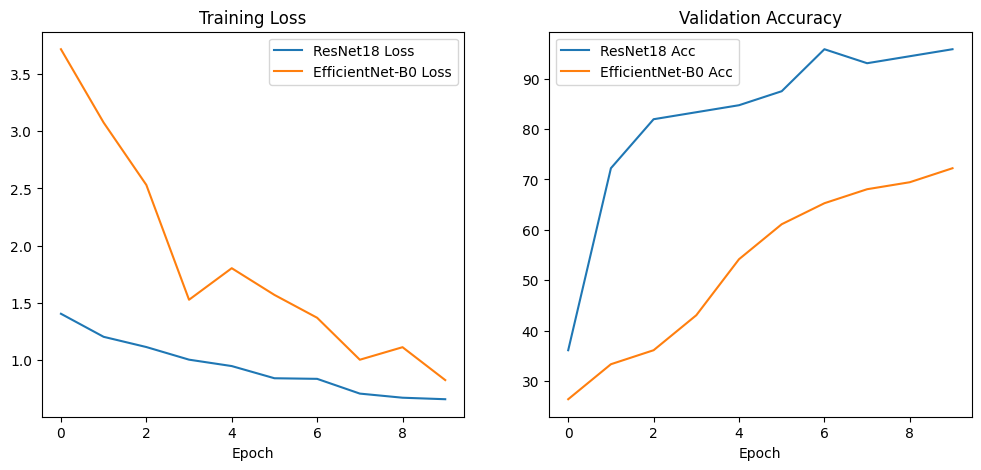

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_resnet['train_loss'], label='ResNet18 Loss')
plt.plot(hist_effnet['train_loss'], label='EfficientNet-B0 Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_resnet['val_acc'], label='ResNet18 Acc')
plt.plot(hist_effnet['val_acc'], label='EfficientNet-B0 Acc')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()


Матрица ошибок для лучшей модели

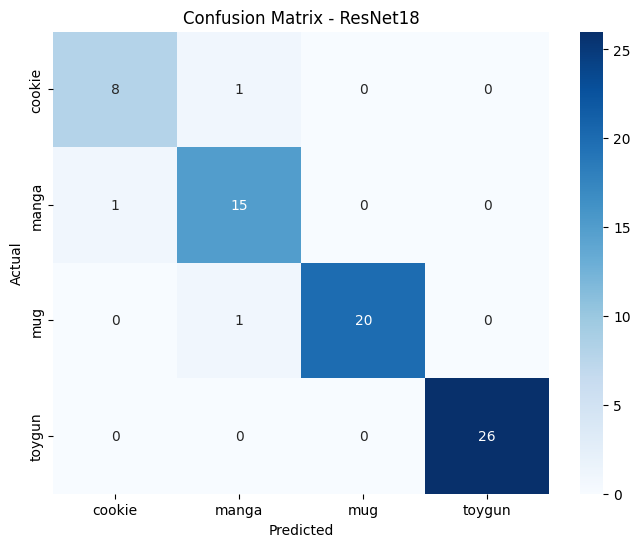

Classification Report:
               precision    recall  f1-score   support

      cookie       0.89      0.89      0.89         9
       manga       0.88      0.94      0.91        16
         mug       1.00      0.95      0.98        21
      toygun       1.00      1.00      1.00        26

    accuracy                           0.96        72
   macro avg       0.94      0.94      0.94        72
weighted avg       0.96      0.96      0.96        72



In [6]:
cm = confusion_matrix(y_true_res, y_pred_res)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ResNet18')
plt.show()

print("Classification Report:\n", classification_report(y_true_res, y_pred_res, target_names=class_names))